# COMPSCI 367: Artificial Intelligence
## Assignment 2: Local Search, Adversarial Search and Logic
Lecturer: Di Zhao

School of Computer Science, University of Auckland

Last updated 25th of September, 2026

Tasks 1 and 2 are adapted from material by Anna Trofimova.

### Copyright statement

© 2026 University of Auckland, School of Computer Science. All rights reserved.

_This assignment is the intellectual property of the University of Auckland and is protected by copyright law. Unauthorised copying, distribution, display, or posting of this material in any form or by any means, including digital or electronic methods, without the prior written permission of the course coordinator is strictly prohibited. This prohibition includes but is not limited to posting this material on websites, forums, or any other public or private platforms. Violators will be subject to legal action and may face academic consequences._

### Student:

Percival Dracott, PDRA239, 294273427

### Submission Guidelines

To successfully complete **Assignment 2**, students are required to submit the following components:

1. **Jupyter Notebook**
   - Filename: `a2.ipynb`
   - The notebook must include all relevant source code, responses to questions, and explanatory text.
   - Students may insert additional code or markdown cells to structure and clarify their work.
   - **Please ensure your full name, UPI, and student ID are entered in the designated markdown cell above** (double-click the cell to edit).

<br>

2. **Compressed Archive of GenAI Interactions**
   - As outlined in the section titled *Use of GenAI* (introduced later in this notebook), students are expected to document their interactions with GenAI tools used during the assignment.
   - These records should be downloaded and compiled into a single `genai.zip` archive.
   - The archive must be submitted alongside the notebook.

**Important Notes**:
All files must be submitted via the **Canvas** upload function by the specified deadline. Please **do not** submit or modify `search.py`, `problem.py` or `csp.py`. Failure to comply with these instructions may result in penalties or rejection of the submission.

The submission deadline is **6th of October at 11.59pm, 2026.**

### Use of GenAI

In this assignment you are permitted to use Google Gemini.

<br>
<div style="background-color: #e6f4ea; border-left: 6px solid #34a853; padding: 10px; font-size: 14px;">
There are no restrictions on the types of questions you may ask, and you are welcome to interact with Google Gemini in the language you are most comfortable with.
</div>


To ensure transparency you are required to document your interactions with Gemini. Specifically:

- Use a new chat for each of Task 1, Task 2, Task 3 and Part B.
- After you complete a task, use the **Convert chat to PDF** button in the top right corner. Name each PDF file "Task X.pdf", where X is the task number, and name the file for Part B "Part B.pdf".
- Compile all saved PDF files into a single `genai.zip` archive.
- Submit this archive along with your Jupyter notebook as part of your assignment.

You will have the opportunity to reference your interactions within your notebook to support your responses or explain your approach.

#### Important Notes:
<br>
<div style="background-color: #ffdddd; border-left: 6px solid #f44336; padding: 10px;">
By submitting any answer or code generated by AI in this notebook, you acknowledge and accept responsibility for its correctness. You agree that the submitted AI-generated content is accurate and meets the assignment requirements.
</div>


While you are permitted to use Generative AI (GenAI) in any way that supports your work on this assignment, you are **strongly encouraged** to first attempt the tasks independently, without GenAI assistance. This is a recommendation only, not a requirement. Attempting the tasks on your own can help you engage more deeply with the material and strengthen your understanding.

There will be **no penalties** for using GenAI, provided that your interactions are properly documented and submitted as instructed.

### Plagiarism

This is an individual assignment. Remember that **all** work submitted for this assignment must be your own **individual** work and no code sharing or copying is allowed. Use of GenAI tools does not excuse you from the responsibility of ensuring the correctness of the code or answers. **Do not use public code repositories as your code or answers might be copied.** Keep in mind that sharing parts of assignment solutions is a form of plagiarism. All submitted assignments will be run through plagiarism detection software to detect similarities to other submissions. It is your responsibility to familiarise yourself with the UoA policy on academic integrity and plagiarism.

If you used any external resources to complete this assignment, please reference them and describe how you used them at the end of this notebook.

### Structure and marks

| Part | Task | Marks |
|------|------|-------|
| A. Search (code) | Task 1: Modelling CSPs and Genetic Algorithms | 5 |
| | Task 2: Hill Climbing with Sideways Moves | 5 |
| | Task 3: Adversarial Search (Alpha-Beta Pruning) | 5 |
| B. Logic (written) | Questions 1-8 | 15 |
| | **Total** | **30** |

This assignment counts towards 5% of your final mark.

### Background

In real-life scenarios, you will rarely write code from scratch. Instead, you will often rely on libraries, frameworks, and pre-built classes to build robust and scalable applications. This assignment aims to simulate such a scenario by providing you with a set of classes in `search.py`, `problem.py` and `csp.py`. Your task is to understand these classes and utilise them to solve the problems given in this assignment.

Below there are libraries that you most likely will need to use to complete this assignment. Run the cell below to import them.

In [37]:
# provided by the assignment
from search import *
from csp import *
from problem import *

# used for visualisation
import networkx as nx
import matplotlib.pyplot as plt

# useful
import math
import random
from copy import deepcopy

If you plan to use any additional libraries, please contact the course coordinator for approval.

# Part A: Search

Part A has three tasks. You will write code for each, and each ends with a short reflection.

## Task 1 - Modelling CSPs and Genetic Algorithms [5 marks]

### Task 1.1 [1 mark]

In this task, you will design your own Constraint Satisfaction Problem using the `CSP` class.

Imagine you are given a sequence of $n$ numbers. Between each pair of adjacent numbers there is a placeholder for one of the operations `+`, `-`, `*` and `/`. Your goal is to determine which operation should go in each position so that the entire expression evaluates to a given target value.

<div style="background-color: #fff3cd; border-left: 6px solid #ff9800; padding: 10px; font-size: 14px;">
Evaluate every expression in this task with the usual precedence: <code>*</code> and <code>/</code> before <code>+</code> and <code>-</code>, and left to right within the same level. Division is exact (for example, 3 / 2 = 1.5).
</div>

In the cell below, initialise the problem using class `CSP`.

In [38]:
# ----- Starter code (don't change this) -----
numbers = [2, 3, 24, 3]
target = 14
operations = ["+", "-", "*", "/"]

# ----- Define domain -----
domain = operations  # each operator slot can be one of "+", "-", "*", "/"

# ----- Define variables -----
# one variable per gap between adjacent numbers: 4 numbers -> 3 gaps
op_variables = [Variable(f"op{i}", domain) for i in range(len(numbers) - 1)]

# ----- Define constraints -----
def evaluates_to_target(*ops):
    # Build e.g. "2*3+24/3" and evaluate it with normal operator precedence
    expr = str(numbers[0])
    for op, n in zip(ops, numbers[1:]):
        expr += f"{op}{n}"
    try:
        return abs(eval(expr) - target) < 1e-9
    except ZeroDivisionError:
        return False

op_constraints = [
    Constraint(tuple(op_variables), evaluates_to_target,
               f"numbers with operators evaluate to {target}")
]

# ----- Solve CSP (don't change this) -----
op_csp = CSP("Operations Placement Problem", op_variables, op_constraints)
op_path = Searcher(op_csp).search()
print(op_path.end() if op_path else "No solution found")

{op0: '*', op1: '+', op2: '/'}


### Task 1.2 [1 mark]

In this task, you will design another Constraint Satisfaction Problem.

Imagine you are given a sequence of $n$ operations, each one of `+`, `-`, `*` and `/`, and a list of $m$ numbers. Your goal is to place numbers from the list around the operations (one number before the first operation, one between each pair of adjacent operations, and one after the last operation) so that the expression evaluates to the given target value. Each number from the list can be used at most once. Evaluate expressions exactly as in Task 1.1.

In the cell below, initialise the problem using class `CSP`.

In [39]:
# ----- Starter code (don't change this) -----
numbers = [1, 2, 3, 4, 5, 6, 7, 8]
target = 17
operations = ["*", "+", "-", "/", "+"]

# ----- Define domain -----
domain = numbers

# ----- Define variables -----
# n operations -> n + 1 number slots
np_variables = [Variable(f"n{i}", domain) for i in range(len(operations) + 1)]

# ----- Define constraints -----
# Each list item used at most once: pairwise "different index" constraints
np_constraints = [
    Constraint((a, b), lambda x, y: x != y, f"{a} != {b}")
    for i, a in enumerate(np_variables)
    for b in np_variables[i + 1:]
]

def evaluates_to_target(*vals):
    # Interleave chosen numbers with the fixed operations: n0 op0 n1 op1 n2 ...
    expr = str(vals[0])
    for op, v in zip(operations, vals[1:]):
        expr += f"{op}{v}"
    try:
        return abs(eval(expr) - target) < 1e-9
    except ZeroDivisionError:
        return False

np_constraints.append(
    Constraint(tuple(np_variables), evaluates_to_target,
               f"expression evaluates to {target}")
)

# ----- Solve CSP (don't change this) -----
np_csp = CSP("Numbers Placement Problem", np_variables, np_constraints)
np_path = Searcher(np_csp).search()
print(np_path.end() if np_path else "No solution found")

{n0: 1, n1: 4, n2: 7, n3: 6, n4: 3, n5: 8}


### Task 1.3 [1 mark]

A Genetic Algorithm (GA) can also be used to search for a solution to both CSPs. In the cell below, for **each** of the two CSPs:

- Describe what a chromosome would look like, and give an example chromosome.
- Describe how crossover could be applied to two chromosomes, and give an example of one-point crossover of two chromosomes with crossing site $c = 2$ (as in lectures, positions are counted from 1: the children are $s_1 s_2\, t_3 \cdots t_l$ and $t_1 t_2\, s_3 \cdots s_l$).
- Describe what a mutation would look like.

Finally, for the CSP in Task 1.2: can crossover produce a chromosome that uses the same number twice? If so, what could you do about it?

#### Your answer:

##### For Task 1.1:

Chromosomes would be a solution representation, for task 1.1 as the number layout is fixed this would be the positions of the operators within the expression. Such as `s = ( *, +, / )`, a chromosome for this could be represented as an array of chars representing the operators.

Crossover could be applied using a simple one point crossover, as operators can be repeated there's no need for more complex crossover methods such as cycle crossover.

`One-Point Crossover at index = 1`

`s = ( *, +, / )`

`t = ( -, /, + )`

`child 1 = s1 s2 t3 = ( *, +, + )`

`child 2 = t1 t2 s3 = ( -, /, / )`

Mutation could be implemented as a random swap, randomly picking an index in the chromosome, and swapping with a random operator from the `operators` array

`s = ( *, +, / )`

`index = 2 -> s = ( *, +, _ )`

`random = 3 -> operations = ["*", "+", "-", "/", "+"] -> "-"`

`insert -> s1 = ( *, +, - )`

##### For Task 1.2:

Chromosomes would be a solution representation, for task 1.2 this is an array of number indexes representing the numbers found in the `numbers` array. As shown `(n₀, n₁, n₂, n₃, n₄, n₅)`.

In 1.2, as number are not allowed to repeat in each solution, we must have an extra step if we wish to use a simple crossover method such as one-point. This extra step would scan through the child solutions and replace duplicates with a value missing from the solution. Alternatively a more complex method such as cycle crossover could be used.

`One-Point Crossover at index = 2`

`s = ( 6, 2, 5, 1, 4, 3 )`

`t = ( 8, 7, 1, 6, 2, 4 )`


`child 1 = s1 s2 t3 t4 t5 t6 = ( 6, 2, 1, 6, 2, 4 )`

`child 2 = t1 t2 s3 s4 s5 s6 = ( 8, 7, 5, 1, 4, 3 )`

`child 1 duplicates 6 and 2`

`child 1 is missing {3,5,7,8}`

`Take two randomly from the missing value array`

`R = 1, R = 3`

`child 1 = s1 s2 t3 t4 t5 t6 = ( 6, 2, 1, 5, 8, 4 )`

`child 2 = t1 t2 s3 s4 s5 s6 = ( 8, 7, 5, 1, 4, 3 )`

Mutation could be implementing using a random swap, swapping numbers at two different indexes in the chromosome. This would provide a different solution output value, however wouldn't change the numbera selected within the chromosome, this would limit how exploratory the mutation would be, potentially leading to getting stuck in local optima. Alternatively randomly swapping a random index with a random from the array of missing numbers would solve this issue, allowing for a more complete range of possible solutions.

### Task 1.4 [1 mark]

In both CSPs, the fitness function guides the GA towards a solution. As in lectures, fitness is **maximised**, and parents are selected with probability **proportionate to their fitness**. In the cell below, answer the following questions:

- Can we use the number of violated constraints as a fitness function? Explain your answer.
- Can we use $1/(1 + \text{number of violated constraints})$ as a fitness function? Explain your answer.
- What behaviour of the GA do you expect in each case?

#### Your answer:

An ideal / goal solution would have no constraints violated, therefore as it stands it would not be a viable replacement for a objective fitness function.

$1/(1 + \text{number of violated constraints})$ would be a valid alternative fitness function in most CSPs.

In the two example exercises above, as they have so few constraints, the $1/(1 + \text{number of violated constraints})$ results in a near binary result. This gives the algorithm very minimal guidance if a candidate solution is close to the goal state, this results in a near random and exhaustive search. This is not a major issue for the examples above as the search spaces are very small and can therefore be brute forced. In an example with a similarly low number of constraints, but a large search space this would not be a viable alternative to a true objective fitness function, as they would require more guidance from a fitness score.


### Task 1.5 [1 mark]

Write a reflection of 5-10 sentences on your approach to completing this task.

If you used Gemini for this task, address the following:

- Clearly state that you used Gemini.
- What did you initially find difficult?
- How did Gemini help?
- What advice or suggestions did you choose not to follow, and why?

If you did not use Gemini for this task, address the following:

- Clearly state that you did not use Gemini or any other GenAI tool.
- What aspects of the task did you find challenging?
- How did you overcome these challenges?
- What did you learn while completing the task?

#### Your answer:

(double click to insert your answer here)

## Task 2 - Hill Climbing with Sideways Moves [5 marks]

The 8-Queens Problem is a classic constraint satisfaction problem (CSP): place 8 queens on a chessboard so that no two queens attack each other, that is, no two queens share a row, a column or a diagonal. In this task, you will evaluate hill climbing with sideways moves on the 8-Queens problem.

### Task 2.1 [0.5 marks]

In the cell below, initialise the problem using class `CSP`. Use one variable per column, whose value is the row (from 0 to 7) of the queen in that column. With this formulation, no two queens can share a column.

In [40]:
# ----- Define domain -----
q_domain = list(range(8))   # was: set(range(8))   # row index 0-7

# ----- Define variables -----
# One variable per column; its value is the row of the queen in that column
q_variables = [Variable(f"Q{c}", q_domain) for c in range(8)]

# ----- Define constraints -----
q_constraints = []

def no_attack(col_gap):
    # Returns a condition for two queens whose columns are col_gap apart
    def cond(r1, r2):
        return r1 != r2 and abs(r1 - r2) != col_gap   # different row, different diagonal
    return cond

for i in range(8):
    for j in range(i + 1, 8):
        q_constraints.append(
            Constraint((q_variables[i], q_variables[j]),
                       no_attack(j - i),
                       f"Q{i} and Q{j} do not attack")
        )

# ----- Solve CSP (don't change this) -----
q_csp = CSP("8-Queens Problem", q_variables, q_constraints)
q_path = Searcher(q_csp).search()
print(q_path.end() if q_path else "No solution found")

{Q0: 0, Q1: 4, Q2: 7, Q3: 5, Q4: 2, Q5: 6, Q6: 1, Q7: 3}


### Task 2.2 [1.5 marks]

`HillClimbingSearcher` in `search.py` implements hill climbing with sideways moves, as defined in lectures:

- A *neighbour* of an assignment changes the value of one variable. At each step the searcher moves to a randomly chosen neighbour with **fewer** violated constraints.
- Only when no such neighbour exists does it make a **sideways** move, to a randomly chosen neighbour with the **same** number of violated constraints. At most `side_moves` sideways moves can be made in a row; the count starts again after every improving move.
- It stops at a solution, or when it can make neither an improving move nor a sideways move.

A single run looks like this:

```python
random.seed(1)
searcher = HillClimbingSearcher(q_csp, side_moves=0)
assignment, violations = searcher.search()   # 0 violations: a solution
print(violations, searcher.steps)            # steps: the number of moves made
```

Run the searcher on your 8-Queens CSP for each number of sideways moves in the table below. For each setting:

- Run the algorithm 100 times, calling `random.seed(s)` immediately before each run, for `s` from 1 to 100.
- For each run, record whether a solution was found, and the number of steps (moves) the algorithm made before it stopped (count these for failed runs too).

The first row has been filled in for you; use it to check your set-up.

In [41]:
# insert your code here
import random

side_moves_values = [0, 5, 10, 20,30,40, 50, 100]
n_runs = 100

results = {}   # side_moves -> list of (solved, steps)

for sm in side_moves_values:
    runs = []
    for s in range(1, n_runs + 1):
        random.seed(s)                                   # immediately before each run
        searcher = HillClimbingSearcher(q_csp, side_moves=sm)
        assignment, violations = searcher.search()
        runs.append((violations == 0, searcher.steps))   # steps counted for failed runs too
    results[sm] = runs

# ----- Summary table -----
print(f"{'side_moves':>10} | {'solved':>6} | {'success %':>9} | {'avg steps (all)':>15} | "
      f"{'avg steps (solved)':>18} | {'avg steps (failed)':>18}")
print("-" * 92)
for sm, runs in results.items():
    solved = [st for ok, st in runs if ok]
    failed = [st for ok, st in runs if not ok]
    avg = lambda xs: f"{sum(xs) / len(xs):.2f}" if xs else "n/a"
    print(f"{sm:>10} | {len(solved):>6} | {100 * len(solved) / n_runs:>8.0f}% | "
          f"{avg([st for _, st in runs]):>15} | {avg(solved):>18} | {avg(failed):>18}")


side_moves | solved | success % | avg steps (all) | avg steps (solved) | avg steps (failed)
--------------------------------------------------------------------------------------------
         0 |     14 |       14% |            4.99 |               6.21 |               4.79
         5 |     46 |       46% |            9.57 |               8.33 |              10.63
        10 |     57 |       57% |           12.12 |               9.58 |              15.49
        20 |     77 |       77% |           15.44 |              12.74 |              24.48
        30 |     82 |       82% |           17.37 |              13.99 |              32.78
        40 |     82 |       82% |           18.97 |              13.99 |              41.67
        50 |     83 |       83% |           20.57 |              14.49 |              50.24
       100 |     90 |       90% |           25.96 |              19.29 |              86.00


Record your results in the table below:

|Side moves| # Solved | Av. Num. of Steps when Solved | # Failed | Av. Num. of Steps when Failed |
|----------|----------|-------------------------------|----------|-------------------------------|
|0         |14        |6.21                           |86        |4.79                           |
|5         |46        |8.33                           |54        |10.63                          |
|10        |57        |9.58                           |43        |15.49                          |
|20        |77        |12.74                          |23        |24.48                          |
|30 |     82 |       82% |           17.37 |              13.99 |              32.78|
|40 |     82 |       82% |           18.97 |              13.99 |              41.67|
|50        |83        |14.49                          |17        |50.24                          |
|100       |90        |19.29                          |10        |86.00                          |

### Task 2.3 [2 marks]

Now suppose hill climbing is run **with random restarts**: after a failed run, it starts again from a new random assignment, until a run finds a solution. Measure efficiency by the expected total number of moves needed to find a solution. If a single run succeeds with probability $p$, taking $S_{\text{solved}}$ moves on average when it succeeds and $S_{\text{failed}}$ moves on average when it fails, then, as in lectures,

$$\text{expected moves} = S_{\text{solved}} + \frac{1-p}{p}\, S_{\text{failed}}.$$

Estimate $p$, $S_{\text{solved}}$ and $S_{\text{failed}}$ for each setting from your table.

Based on the results in your table, which number of sideways moves would you choose? Justify your answer with computations (and, if you like, a plot).

#### Your answer:

side_moves=  0: p=0.14, expected moves=35.64
side_moves=  5: p=0.46, expected moves=20.80
side_moves= 10: p=0.57, expected moves=21.26
side_moves= 20: p=0.77, expected moves=20.05
side_moves= 30: p=0.82, expected moves=21.18
side_moves= 40: p=0.82, expected moves=23.13
side_moves= 50: p=0.83, expected moves=24.78
side_moves=100: p=0.90, expected moves=28.84
Best: 20 20.051948051948052


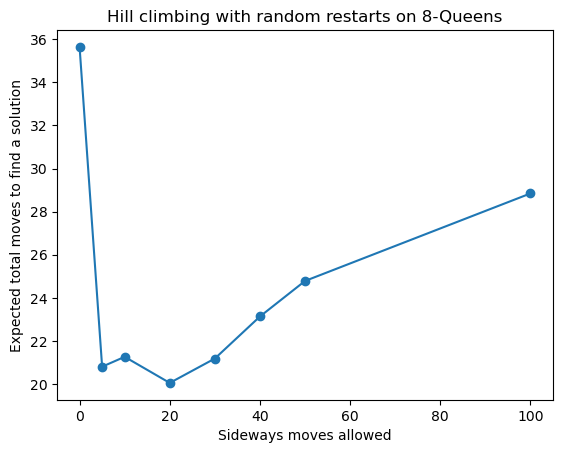

In [42]:
# insert your code here (optional)
import matplotlib.pyplot as plt

expected = {}
for sm, runs in results.items():
    solved = [st for ok, st in runs if ok]
    failed = [st for ok, st in runs if not ok]
    p = len(solved) / len(runs)
    s_solved = sum(solved) / len(solved)
    s_failed = sum(failed) / len(failed) if failed else 0
    expected[sm] = s_solved + (1 - p) / p * s_failed
    print(f"side_moves={sm:>3}: p={p:.2f}, expected moves={expected[sm]:.2f}")

best = min(expected, key=expected.get)
print("Best:", best, expected[best])

plt.plot(list(expected), list(expected.values()), marker="o")
plt.xlabel("Sideways moves allowed")
plt.ylabel("Expected total moves to find a solution")
plt.title("Hill climbing with random restarts on 8-Queens")
plt.show()


With 0 sideways moves, p is only 0.14, so many restarts are needed and the cost is high. A few sideways moves raise p sharply (0.77 at 20), cutting the cost to about 20. Beyond 20, p improves only slowly while failed runs get much longer (24 to 86 steps), so the expected cost rises again.

I would choose 20 sideways moves, which has the lowest expected cost (about 20.05 moves). The values for 5 to 30 are close, so with only 100 runs per setting the exact best in that range is uncertain, but 0 and 100 are clearly worse. This would only apply to the dataset above, and is likely overfitted to the dataset, and would therefore ahve very minimal transfer to other or extended datasets or CPS problems

### Task 2.4 [1 mark]

Write a reflection of 5-10 sentences on your approach to completing this task.

If you used Gemini for this task, address the following:

- Clearly state that you used Gemini.
- What did you initially find difficult?
- How did Gemini help?
- What advice or suggestions did you choose not to follow, and why?

If you did not use Gemini for this task, address the following:

- Clearly state that you did not use Gemini or any other GenAI tool.
- What aspects of the task did you find challenging?
- How did you overcome these challenges?
- What did you learn while completing the task?

#### Your answer:

(double click to insert your answer here)

## Task 3 - Adversarial Search: Alpha-Beta Pruning [5 marks]

The cell below defines a game tree using class `GameTree` from `problem.py`. MAX moves at the root `A`; MIN moves at `B`, `C` and `D`; MAX moves again at `E` to `M`. Every leaf is written as a number, which is its utility for MAX. The children of each node are listed in the order in which a search visits them.

Run the cell below to visualise the tree.

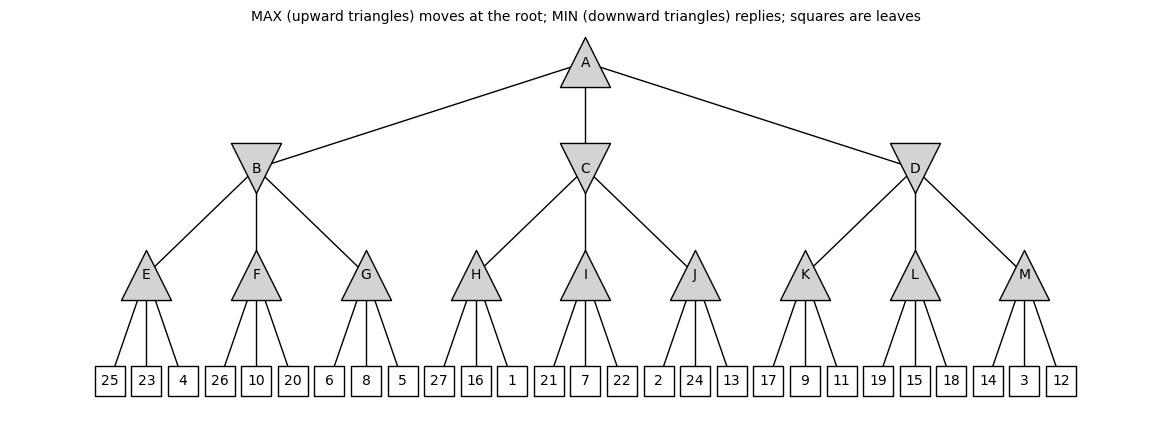

In [43]:
children = {
    'A': ['B', 'C', 'D'],
    'B': ['E', 'F', 'G'],
    'C': ['H', 'I', 'J'],
    'D': ['K', 'L', 'M'],
    'E': [25, 23, 4],
    'F': [26, 10, 20],
    'G': [6, 8, 5],
    'H': [27, 16, 1],
    'I': [21, 7, 22],
    'J': [2, 24, 13],
    'K': [17, 9, 11],
    'L': [19, 15, 18],
    'M': [14, 3, 12],
}

game_tree = GameTree(children, root='A')
game_tree.show()

`MinimaxSearcher` in `search.py` implements minimax as in lectures (Minimax-Decision, Max-Value and Min-Value). Its `search` method returns the minimax value of the root and the move to play (the child of the root that achieves that value), and it counts the leaves it evaluates in `num_leaves`. Run the cell below.

In [44]:
minimax = MinimaxSearcher(game_tree)
value, move = minimax.search()
print(f"Minimax: value {value}, move {move}, leaves evaluated {minimax.num_leaves}")

Minimax: value 22, move C, leaves evaluated 27


### Task 3.1 [2 marks]

In the cell below, implement alpha-beta pruning as discussed in lectures by extending class `MinimaxSearcher`:

- Override `max_value` and `min_value` so that each also takes the bounds `alpha` and `beta`, as in the lectures' pseudocode: a MAX node stops searching as soon as $v \geq \beta$, and otherwise sets $\alpha \gets \max(\alpha, v)$; a MIN node stops as soon as $v \leq \alpha$, and otherwise sets $\beta \gets \min(\beta, v)$.
- Override `search` so that it treats the root as a MAX node: start with $\alpha = -\infty$ and $\beta = +\infty$, update $\alpha$ after each child of the root as Max-Value does, and return the value of the root and the move to play, just as `MinimaxSearcher.search` does.
- Count the leaves your search evaluates in `self.num_leaves`, exactly as `MinimaxSearcher` does.

In [45]:
class AlphaBetaSearcher(MinimaxSearcher):

    def search(self):
        """Alpha-beta search from the root (a MAX node). Returns (value, move)."""
        self.num_leaves = 0
        alpha, beta = float('-inf'), float('inf')
        best_value, best_move = float('-inf'), None
        for child in self.tree.children(self.tree.root):
            v = self.min_value(child, alpha, beta)
            if v > best_value:            # strict: first child achieving the best value
                best_value, best_move = v, child
            alpha = max(alpha, v)
        return best_value, best_move

    def max_value(self, node, alpha=float('-inf'), beta=float('inf')):
        """Value of a MAX node, pruning when v >= beta."""
        if self.tree.is_leaf(node):
            self.num_leaves += 1
            return self.tree.utility(node)
        v = float('-inf')
        for child in self.tree.children(node):
            v = max(v, self.min_value(child, alpha, beta))
            if v >= beta:
                return v                  # MIN above will never allow this node
            alpha = max(alpha, v)
        return v

    def min_value(self, node, alpha=float('-inf'), beta=float('inf')):
        """Value of a MIN node, pruning when v <= alpha."""
        if self.tree.is_leaf(node):
            self.num_leaves += 1
            return self.tree.utility(node)
        v = float('inf')
        for child in self.tree.children(node):
            v = min(v, self.max_value(child, alpha, beta))
            if v <= alpha:
                return v                  # MAX above will never allow this node
            beta = min(beta, v)
        return v

Run the cell below to test your implementation on the same tree.

In [46]:
alpha_beta = AlphaBetaSearcher(game_tree)
value, move = alpha_beta.search()
print(f"Alpha-beta: value {value}, move {move}, leaves evaluated {alpha_beta.num_leaves}")

Alpha-beta: value 22, move C, leaves evaluated 18


Record the results of both searches in the table below:

| Algorithm  | Value | Move | Leaves evaluated |
|------------|-------|------|------------------|
| Minimax    |   22    |    c  |     27             |
| Alpha-beta |  22     |    c  |      18            |

### Task 3.2 [1 mark]

The number of leaves alpha-beta evaluates depends on the order in which children are visited. Without changing the shape of the tree or the value of any leaf, **only reordering the children of nodes**:

- find an ordering for which alpha-beta evaluates as **few** leaves as possible, and
- find an ordering for which alpha-beta evaluates as **many** leaves as possible.

Define both orderings in the cell below (as `best_children` and `worst_children`), then run the cell.

In [48]:
best_children = deepcopy(children)
worst_children = deepcopy(children)
# insert your code here (reorder the lists in best_children and worst_children)
ref_tree = GameTree(children, root='A')
node_value, node_is_max = {}, {}

def evaluate(node, is_max):
    node_is_max[node] = is_max
    if ref_tree.is_leaf(node):
        node_value[node] = ref_tree.utility(node)
    else:
        vals = [evaluate(c, not is_max) for c in ref_tree.children(node)]
        node_value[node] = max(vals) if is_max else min(vals)
    return node_value[node]

evaluate('A', True)

# ----- Reorder the children of every internal node -----
for node in children:
    if node not in node_is_max:        # skip anything unreachable from the root
        continue
    is_max = node_is_max[node]
    # Best: MAX tries its highest-valued child first, MIN its lowest-valued child first
    best_children[node].sort(key=lambda c: node_value[c], reverse=is_max)
    # Worst: the opposite, so the strongest child is found last
    worst_children[node].sort(key=lambda c: node_value[c], reverse=not is_max)

for name, kids in [("Best ordering", best_children), ("Worst ordering", worst_children)]:
    searcher = AlphaBetaSearcher(GameTree(kids, root='A'))
    value, move = searcher.search()
    print(f"{name}: value {value}, move {move}, leaves evaluated {searcher.num_leaves}")

Best ordering: value 22, move C, leaves evaluated 11
Worst ordering: value 22, move C, leaves evaluated 27


Record your results in the table below:

| Ordering         | Value | Move | Leaves evaluated |
|------------------|-------|------|------------------|
| Given (Task 3.1) |    22   |   c   |        27          |
| Best             |     22  |   c   |     11             |
| Worst            |    22   |    c  |       27           |

### Task 3.3 [1 mark]

Reflect on the results in your tables and answer the following questions in the cell below:

- Did reordering change the value of the root or the move chosen? Explain why or why not.
- What makes an ordering good or bad for alpha-beta pruning?
- In lectures, perfect ordering reduces the cost of alpha-beta from $O(b^m)$ to $O(b^{m/2})$. How do your counts compare with $b^m$ and $b^{m/2}$ for this tree ($b = 3$, $m = 3$)?

#### Your answer:

Reording optimised the tree for AB Pruning, resulting in a near perfect prune. Reducing the number of nodes evaluated from 27 in standard MiniMax to 11, with the optimised tree.

Reordering the tree results in an improved performance as it places high scores early in the MAX search path, raising the Alpha value high early on increasing the number of branches pruned. Likewise MIN node visits it's lowest value first making Beta the lowest possible value to increase number of Min pruned branches.

By contrast for the Sub-optimal tree the opposite happens, where each AB pruning decision results in the branch being explored as the highest MAX node and lowest MIN node are at the end of the search path, meaning Alpha and Beta constanly are overwritten as the search progresses.

`Given / Worse : 3^3 = 27` - As given, nothing gets pruned in the worst case.
                
`Best Ordering : 3^(3/2) = 5.2` - Higher than theoretical as B^M drops static costs within the Big-Oh notation.

### Task 3.4 [1 mark]

Write a reflection of 5-10 sentences on your approach to completing this task.

If you used Gemini for this task, address the following:

- Clearly state that you used Gemini.
- What did you initially find difficult?
- How did Gemini help?
- What advice or suggestions did you choose not to follow, and why?

If you did not use Gemini for this task, address the following:

- Clearly state that you did not use Gemini or any other GenAI tool.
- What aspects of the task did you find challenging?
- How did you overcome these challenges?
- What did you learn while completing the task?

#### Your answer:

(double click to insert your answer here)

# Part B: Logic

Part B has eight questions. Answer each in the markdown cell below it; no code is needed. You may type logical symbols directly (¬ ∧ ∨ → ↔ ∀ ∃ ←) or write LaTeX between dollar signs, e.g. `$\forall x\, (P(x) \rightarrow Q(x))$`.

### Question 1 [1 mark]

The following biological relations are expressed in propositional logic. Translate its meaning into English.

<div style="margin-left: 3em; line-height: 1.8;">
John_father_of_Mark ∧ John_father_of_Luke<br>
∧ Sara_mother_of_Mark ∧ Sara_mother_of_Luke<br>
∧ Mark_is_male<br>
→ Mark_brother_of_Luke
</div>

#### Your answer:

### Question 2 [1 mark]

If we wanted to add to this knowledge base and query whether Bob was the biological uncle of Mark, we would need a proposition in our knowledge base that expresses the condition under which we can infer that *Bob_uncle_of_Mark*. Write that rule in propositional logic. (You may use some of the propositions from question 1.)

#### Your answer:

(double click to insert your answer here)

### Question 3 [1 mark]

We add the following propositions to our knowledge base to indicate sibling relations: *John_sibling_of_Jack*, *John_sibling_of_Jane*, *Sara_sibling_of_Sam*, and *Sara_sibling_of_Shelby*.

In English, write the phrase that would specify the conditions under which Bob would be either a biological uncle of Mark, or an uncle through marriage. (Hint: you may need to mention that someone is the *husband of* someone else.)

#### Your answer:

(double click to insert your answer here)

### Question 4 [2 marks]

Write a sentence in propositional logic that expresses the English phrase from your answer to question 3.

#### Your answer:

(double click to insert your answer here)

### Question 5 [2 marks]

Consider the following proposition:

$$
\begin{aligned}
&(A \vee B) \wedge (\neg A \vee \neg B) \wedge (\neg B \vee \neg C \vee D)\\
&\wedge (C \vee E) \wedge (\neg E \vee \neg A) \wedge (\neg D \vee E) \wedge (\neg E \vee \neg B)\\
&\wedge (E \vee \neg F \vee G) \wedge (\neg F \vee G \vee \neg H) \wedge (\neg G \vee \neg H)\\
&\wedge (F \vee \neg H) \wedge (\neg G \vee H \vee I) \wedge (\neg I \vee \neg J) \wedge (J \vee E \vee \neg A)
\end{aligned}
$$

Determine whether the given propositional formula is satisfiable. If the formula is satisfiable, provide an assignment of truth values (a truth assignment) for variables A, B, C, D, E, F, G, H, I, J that satisfies the formula; write each truth value as *true* or *false*. If it is unsatisfiable, explain why.

#### Your answer:

(double click to insert your answer here)

### Question 6 [2 marks]

Write each of the following in first-order logic.

(6.a) Not all trees are tall

(6.b) No trees are tall

(6.c) Only trees are tall

(6.d) All and only trees are tall

#### Your answer:

(double click to insert your answer here)

### Question 7 [2 marks]

Write a sentence in first-order logic that expresses the conditions under which anyone, *y*, could be an uncle of anyone else, *x*, through either biology or through marriage. Use the relations below. (Full marks for the most concise form.)

*Variables: w, x, y, z*

*Male(x)*<br>
*Parent(x, y)* – x is a parent of y<br>
*Sibling(x, y)* – x is a sibling of y<br>
*Married(x, y)* – x is married to y<br>
*Uncle(x, y)* – x is the uncle of y

#### Your answer:

(double click to insert your answer here)

### Question 8 [4 marks total]

You will build a simple knowledge base, consisting of a set of rules written below (in a slightly abbreviated form). Each rule is written as an implication, expressed in terms of an **if** part (the premise) and a **then** part (the conclusion). For example, rule (2) delivers the following message: "If you are investing for retirement and you have basic insurance coverage, then you should do Kiwisaver".

<div style="margin-left: 2em; line-height: 1.8;">
(1) &nbsp; <b>if</b> <i>have health insurance</i> and <i>have life insurance</i> &nbsp; <b>then</b> <i>basic insurance coverage</i><br>
(2) &nbsp; <b>if</b> <i>invest for retirement</i> and <i>basic insurance coverage</i> &nbsp; <b>then</b> <i>Kiwisaver</i><br>
(3) &nbsp; <b>if</b> <i>age ≤ 65</i> &nbsp; <b>then</b> <i>not retired</i><br>
(4) &nbsp; <b>if</b> <i>age > 65</i> &nbsp; <b>then</b> <i>retired</i><br>
(5) &nbsp; <b>if</b> <i>not retired</i> and <i>no pension plan</i> &nbsp; <b>then</b> <i>invest for retirement</i>
</div>

**(8.a) [2 marks]** Design a definite clause knowledge base using the information above. Clearly list the atomic propositions (with their intended meaning) and the clauses in the KB. An example that contains a few atomic propositions and a rule is given below:

*Example.* Atomic propositions:

- BasInsure: The user has basic insurance cover
- HeaInsure: The user has health insurance
- LifInsure: The user has life insurance

Clause (1): BasInsure ← HeaInsure ∧ LifInsure

#### Your answer:

(double click to insert your answer here)

**(8.b) [2 marks]** Suppose a user has the following information:

<div style="margin-left: 2em; line-height: 1.8;">
(6) &nbsp; is 42 years old<br>
(7) &nbsp; has health insurance, and (8) life insurance<br>
(9) &nbsp; not covered by a pension plan
</div>

Given these additional facts, apply forward chaining on the query: "you should do Kiwisaver". If the answer is true, provide a proof, and answer why if the answer is false.

#### Your answer:

(double click to insert your answer here)

## References

### Gemini Chat Logs

If you followed the required naming convention for your Gemini chat logs (`Task 1.pdf`, `Task 2.pdf`, `Task 3.pdf` and `Part B.pdf`), you do not need to modify the entries below.

#### Task 1
file: Task 1.pdf

#### Task 2
file: Task 2.pdf

#### Task 3
file: Task 3.pdf

#### Part B
file: Part B.pdf


### Additional Resources (if applicable)

List any additional resources used to complete this assignment and briefly describe how they were used.

- Resource:
    - How it was used:

- Resource:
    - How it was used: